# House Price- Advanced Regression Techniques

In this project, we aim to create a regression model to predict house prices using advanced regression techniques. We will be using the 'House Prices- Advanced Regression Techniques' dataset from kaggle. It is a practice project with aim to understand:
- Exploratory Data Analysis
- Preprocessing
- Pipelines
- Regression models
- HyperParameter tuning
- Feature Importances

About the dataset: The dataset is taken from kaggle, it already is a train and test split. There are 80 columns in the dataset we will have to explore 79 features. The dataset contains missing values and requires preprocessing to improve quality.

**Dataset Description:**
| Category                     | Description                                                              | Example Features                                                                      |
| ---------------------------- | ------------------------------------------------------------------------ | ------------------------------------------------------------------------------------- |
| **Identification**           | Unique identifier for each property.                                     | `Id`                                                                                  |
| **Location**                 | Information about the property's geographical location and neighborhood. | `MSZoning`, `Neighborhood`, `Condition1`, `Condition2`                                |
| **Lot Information**          | Characteristics of the land on which the house is built.                 | `LotArea`, `LotShape`, `LotConfig`, `LandContour`, `Street`, `Alley`                  |
| **Building Characteristics** | Structural information about the house.                                  | `BldgType`, `HouseStyle`, `OverallQual`, `OverallCond`, `YearBuilt`, `YearRemodAdd`   |
| **Exterior Features**        | Exterior materials and quality of the house.                             | `RoofStyle`, `RoofMatl`, `Exterior1st`, `Exterior2nd`, `MasVnrType`, `MasVnrArea`     |
| **Basement Features**        | Details regarding basement type, quality, size, and finishing.           | `BsmtQual`, `BsmtCond`, `BsmtExposure`, `TotalBsmtSF`, `BsmtFinSF1`, `BsmtFinType1`   |
| **Heating & Utilities**      | Heating systems, utilities, and electrical systems.                      | `Heating`, `HeatingQC`, `CentralAir`, `Electrical`, `Utilities`                       |
| **Interior Features**        | Room counts, living area, flooring quality, and interior condition.      | `GrLivArea`, `TotRmsAbvGrd`, `KitchenQual`, `BedroomAbvGr`, `FullBath`, `HalfBath`    |
| **Garage Features**          | Garage capacity, construction year, size, and quality.                   | `GarageType`, `GarageYrBlt`, `GarageArea`, `GarageCars`, `GarageFinish`, `GarageQual` |
| **Outdoor Features**         | Porches, decks, pools, fences, and miscellaneous outdoor structures.     | `WoodDeckSF`, `OpenPorchSF`, `PoolArea`, `Fence`, `MiscFeature`                       |
| **Sale Information**         | Details about the sale transaction.                                      | `MoSold`, `YrSold`, `SaleType`, `SaleCondition`                                       |
| **Target Variable**          | Final selling price of the property to be predicted.                     | `SalePrice`                                                                           |


In [5]:
# Import 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [6]:
df = pd.read_csv("../data/train.csv")

In [7]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df.shape, df.size

((1460, 81), 118260)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [10]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [11]:
# Looking at numerical features
num_features = df.select_dtypes(include=['int64', 'float64'])
num_features.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

In [12]:
# Looking at categorical features
cat_features = df.select_dtypes(include=['object', 'str'])
cat_features.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [13]:
# Finding the number of missing values in columns

df.isna().sum().sort_values(ascending=False)[:20]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [14]:
# Convert the missing values in percentages to see how much data is missing from columns.

missing = df.isna().mean()*100
missing.sort_values(ascending=False)[:20]

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

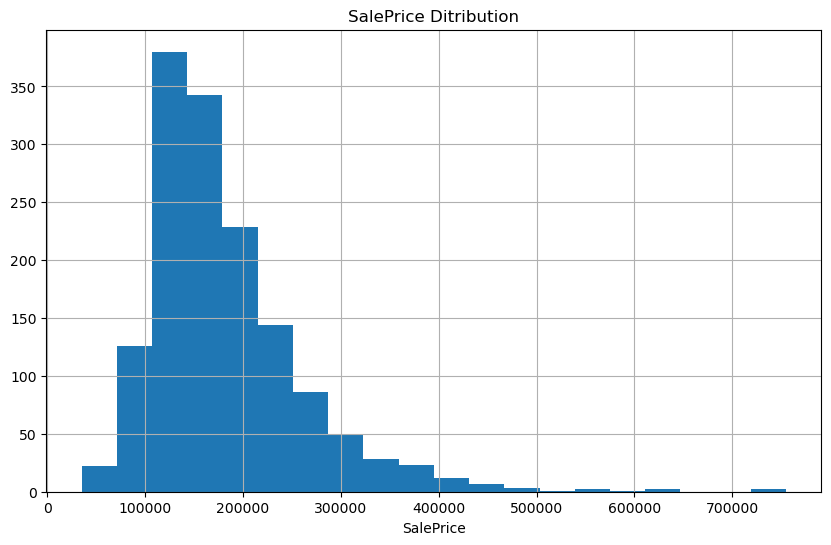

In [15]:
# Let's look at the target variable

df.SalePrice.hist(bins=20, figsize=(10,6))
plt.xlabel("SalePrice")
plt.title("SalePrice Ditribution")
plt.savefig("../images/SalePriceDistribution.png")

We can see that the Sale Price is concentrated between 100000 and 200000. min value is around 50000 and maximum value reaches up to 750000

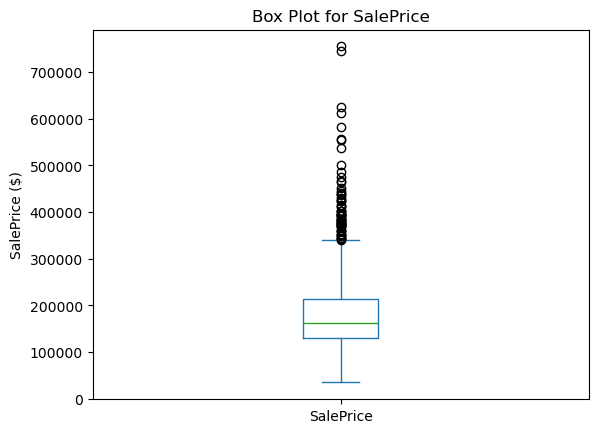

In [16]:
# Boxplot of SalePrice
df.SalePrice.plot(kind='box')
plt.title("Box Plot for SalePrice")
plt.ylabel("SalePrice ($)")
plt.savefig("../images/Boxplot-of-SalePrice")

We can see that the dataset has many outliers in the SalePrice but we cannot change it as it is the target price variable.

In [17]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage" : (df.isna().sum()/len(df))*100,
    "Datatypes": df.dtypes
})
missing = missing[missing["Missing Count"] > 0]
missing.sort_values("Missing Percentage", ascending=False)

,Missing Count,Missing Percentage,Datatypes
PoolQC,1453,99.520548,str
MiscFeature,1406,96.301370,str
Alley,1369,93.767123,str
Fence,1179,80.753425,str
MasVnrType,872,59.726027,str
FireplaceQu,690,47.260274,str
LotFrontage,259,17.739726,float64
GarageType,81,5.547945,str
GarageYrBlt,81,5.547945,float64
GarageFinish,81,5.547945,str




| Feature      | Missing Reason                      | Group | Imputation Strategy                          |
| ------------ | ----------------------------------- | ----- | -------------------------------------------- |
| PoolQC       | House has no pool                   | A     | Fill `"None"`                                |
| MiscFeature  | No miscellaneous feature            | A     | Fill `"None"`                                |
| Alley        | No alley access                     | A     | Fill `"None"`                                |
| Fence        | No fence                            | A     | Fill `"None"`                                |
| FireplaceQu  | No fireplace                        | A     | Fill `"None"`                                |
| GarageType   | No garage                           | A     | Fill `"None"`                                |
| GarageFinish | No garage                           | A     | Fill `"None"`                                |
| GarageQual   | No garage                           | A     | Fill `"None"`                                |
| GarageCond   | No garage                           | A     | Fill `"None"`                                |
| BsmtQual     | No basement                         | A     | Fill `"None"`                                |
| BsmtCond     | No basement                         | A     | Fill `"None"`                                |
| BsmtExposure | No basement                         | A     | Fill `"None"`                                |
| BsmtFinType1 | No basement                         | A     | Fill `"None"`                                |
| BsmtFinType2 | No basement                         | A     | Fill `"None"`                                |
| MasVnrType*  | No masonry veneer / missing info    | A     | Fill `"None"` *(if present in your dataset)* |
| GarageYrBlt  | No garage                           | B     | Fill `0`                                     |
| GarageArea   | No garage                           | B     | Fill `0`                                     |
| GarageCars   | No garage                           | B     | Fill `0`                                     |
| BsmtFinSF1   | No basement                         | B     | Fill `0`                                     |
| BsmtFinSF2   | No basement                         | B     | Fill `0`                                     |
| BsmtUnfSF    | No basement                         | B     | Fill `0`                                     |
| TotalBsmtSF  | No basement                         | B     | Fill `0`                                     |
| BsmtFullBath | No basement                         | B     | Fill `0`                                     |
| BsmtHalfBath | No basement                         | B     | Fill `0`                                     |
| MasVnrArea   | No masonry veneer                   | B     | Fill `0`                                     |
| LotFrontage  | Unknown frontage measurement        | C     | Median (often grouped by `Neighborhood`)     |
| Electrical   | Missing record                      | D     | Most frequent                                |
| KitchenQual* | Missing record (mostly in test set) | D     | Most frequent                                |
| Exterior1st* | Missing record (mostly in test set) | D     | Most frequent                                |
| Exterior2nd* | Missing record (mostly in test set) | D     | Most frequent                                |
| SaleType*    | Missing record (mostly in test set) | D     | Most frequent                                |
| Functional*  | Missing record (mostly in test set) | D     | Most frequent                                |
| Utilities*   | Missing record (mostly in test set) | D     | Most frequent                                |
| MSZoning*    | Missing record (mostly in test set) | D     | Most frequent                                |


In [18]:
from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis = 1)
y = df.SalePrice

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1168, 80), (292, 80), (1168,), (292,))

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [20]:
cat_none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]
num_zero_cols = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]
num_median_cols = [
    "LotFrontage"
]
cat_mode_cols = [
    "Electrical",
    "MSZoning",
    "Utilities",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "Functional",
    "SaleType"
]

remaining_cat_cols = [
    col for col in X_train.select_dtypes(include=["object", 'str']).columns
    if col not in cat_none_cols + cat_mode_cols
]

remaining_num_cols = [
    col for col in X_train.select_dtypes(exclude=["object",'str']).columns
    if col not in num_zero_cols + num_median_cols
]

In [21]:
cat_none_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='constant', fill_value="None")),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

cat_mode_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

num_zero_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

num_median_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_regular_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
num_regular_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [23]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat_none", cat_none_pipeline, cat_none_cols),
        ("cat_mode", cat_mode_pipeline, cat_mode_cols),
        ('cat_regular', cat_regular_pipeline, remaining_cat_cols),
        ("num_zero", num_zero_pipeline, num_zero_cols),
        ("num_median", num_median_pipeline, num_median_cols),
        ("num_regular", num_regular_pipeline, remaining_num_cols)
    ]
)

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [25]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_none', ...), ('cat_mode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [26]:
model.score(X_val,y_val)

0.8694295119899191

In [28]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

y_pred = model.predict(X_val)

print("R²:", r2_score(y_val, y_pred))
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))

R²: 0.8694295119899191
MAE: 18256.716301369863
RMSE: 29860.806958454126


# HyperParameter Tuning
Okay so we observe a R2 score of ~0.87 which is great as it suggests that our model does well for generalizing the features rather than just predicting the mean. The mean_absolute_error suggests that the model error can be +-18256 from original price.

With HyperParameter tuning let us try to increase R2 score and reduce the mean absolute error and rmse.

In [32]:
%%time

param_dist = {
    "regressor__n_estimators" : [100, 300, 500],
    "regressor__max_depth" : [10, 20, None],
    "regressor__min_samples_split" : [2, 5, 10],
    "regressor__min_samples_leaf" : [1,2,4],
    "regressor__max_features": ['sqrt', 'log2']
}

from sklearn.model_selection import RandomizedSearchCV

reg_model = RandomizedSearchCV(estimator=model,
                              param_distributions=param_dist,
                              cv=5,
                              n_iter=20,
                              verbose=2)

reg_model.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=300; total time=   0.7s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=300; total time=   0.6s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=300; total time=   0.6s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=300; total time=   0.7s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=300; total time=   0.5s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt,

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [10, 20, ...], 'regressor__max_features': ['sqrt', 'log2'], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [33]:
reg_model.best_params_

{'regressor__n_estimators': 500,
 'regressor__min_samples_split': 10,
 'regressor__min_samples_leaf': 1,
 'regressor__max_features': 'sqrt',
 'regressor__max_depth': 20}

In [35]:
y_pred = reg_model.predict(X_val)

print("R²:", r2_score(y_val, y_pred))
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))

R²: 0.8410519845872898
MAE: 17665.47138924458
RMSE: 32946.2948783281


#### Model actually performs worse, lets try again with different parameters.

In [40]:
%%time

param_dist = {
    "regressor__n_estimators" : [100,130, 150,180,200],
    "regressor__max_depth" : [15, None],
    "regressor__min_samples_split" : [6, 8],
    "regressor__min_samples_leaf" : [1,2,3],
    "regressor__max_features": ['sqrt']
}

from sklearn.model_selection import RandomizedSearchCV

reg_model = RandomizedSearchCV(estimator=model,
                              param_distributions=param_dist,
                              cv=5,
                              n_iter=30,
                              verbose=2)

reg_model.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=100; total time=   0.4s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=100; total time=   0.3s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=100; total time=   0.3s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=100; total time=   0.3s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_leaf=3, regressor__min_samples_split=8, regressor__n_estimators=100; total time=   0.2s
[CV] END regressor__max_depth=None, regressor__max_fe

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [15, None], 'regressor__max_features': ['sqrt'], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [6, 8], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [41]:
reg_model.best_params_

{'regressor__n_estimators': 100,
 'regressor__min_samples_split': 6,
 'regressor__min_samples_leaf': 1,
 'regressor__max_features': 'sqrt',
 'regressor__max_depth': None}

In [42]:
y_pred = reg_model.predict(X_val)

print("R²:", r2_score(y_val, y_pred))
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))

R²: 0.8414563265193342
MAE: 17680.290227210764
RMSE: 32904.362768186154


wow we can see that even after trying out different parameters, the score just degrades, so i'll just go with base parameters as they give satisfactory results.

## Feature importance plot

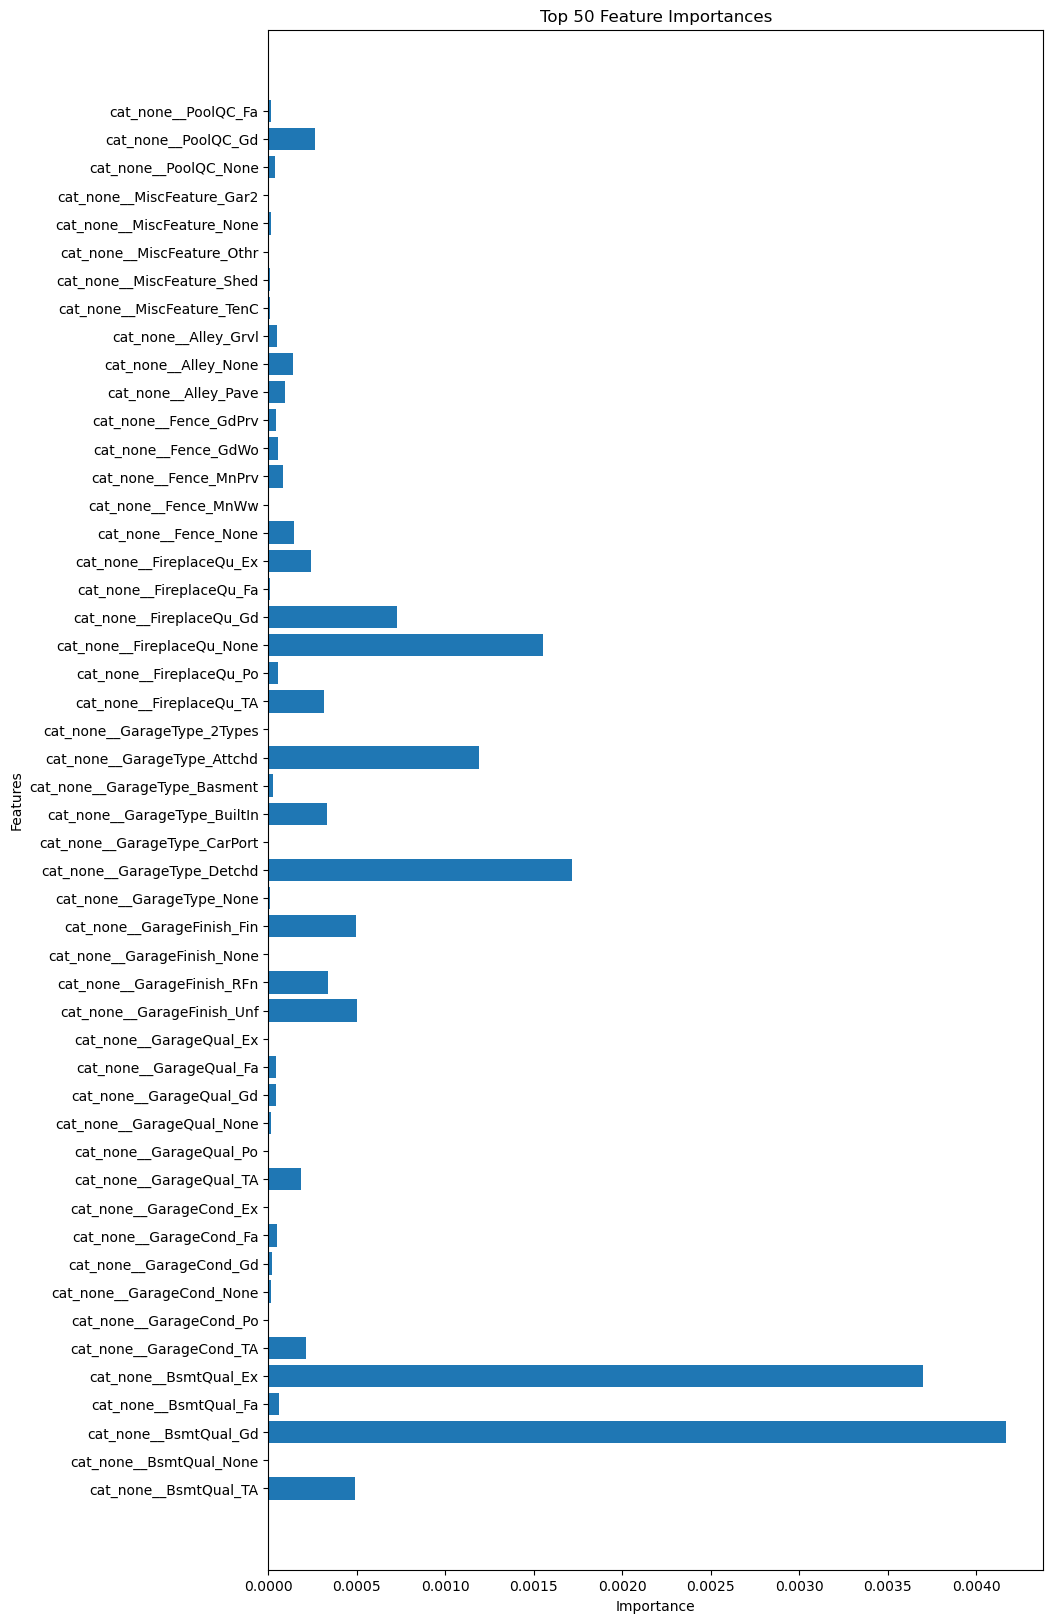

<Figure size 640x480 with 0 Axes>

In [54]:
rf = model.named_steps["regressor"]
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

feature_imp = pd.DataFrame({
    "Feature" : feature_names,
    "Importance" : rf.feature_importances_
})

feature_imp.sort_values(by="Importance", ascending=False)

top = feature_imp.head(50)

# Plot the features
plt.figure(figsize=(10,20))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 50 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()
plt.savefig("../images/feature-importance.png")

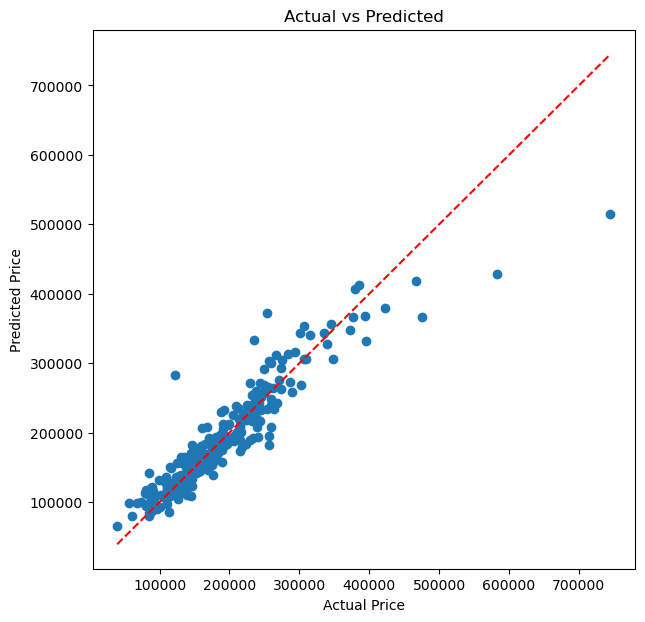

<Figure size 640x480 with 0 Axes>

In [56]:
# Actual vs predicted plot
y_pred = model.predict(X_val)

plt.figure(figsize=(7,7))

plt.scatter(y_val, y_pred)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()
plt.savefig("../images/actual-vs-predicted.png")